This script is to construct a simple 2D underground model, that contains a mesh, with artificial dataset of a ground property (e.g. stiffness) and scale of fluctuation. 

In [1]:
import os
from pathlib import Path
import pyvista as pv
import matplotlib.pyplot as plt
import numpy as np
import vtk
from vtk.util.numpy_support import numpy_to_vtk
import scipy.stats as stats
import subprocess
import os
from pathlib import Path
import math

In [2]:
import generate_random_field_3D  
import Mesh_settings_3D

In the first step, we make some settings. 

To create a mesh, we set the size and number of cells of the mesh.

To assign a ground property (e.g. stiffness) to all the nodes of the mesh, we give the mean and variance for each layer.

If the parameter has a linear relationship with depth, we set the slope. 

To generate a random field, we set the scale of fluctuation. Random seed is to initiate a random field. Same seed can reproduce the same random field.

In [3]:
# import parameters from mesh_settings configuration file

filename = Mesh_settings_3D.filename
width_of_boundary = Mesh_settings_3D.width_of_boundary
length_of_boundary = Mesh_settings_3D.length_of_boundary
depth_of_boundary = Mesh_settings_3D.depth_of_boundary
number_of_cells_x = Mesh_settings_3D.number_of_cells_x
number_of_cells_y = Mesh_settings_3D.number_of_cells_y
number_of_cells_z = Mesh_settings_3D.number_of_cells_z
number_of_layers = Mesh_settings_3D.number_of_layers

stiffness_mean = Mesh_settings_3D.stiffness_mean  # Pa 
slope = Mesh_settings_3D.slope

horizontal_scale_of_fluctuation = Mesh_settings_3D.horizontal_scale_of_fluctuation
vertical_scale_of_fluctuation = Mesh_settings_3D.vertical_scale_of_fluctuation

We create a output directory. All generated files will be put there.

In [4]:
out_dir = Path(os.environ.get("OGS_TESTRUNNER_OUT_DIR", "_out"))
if not out_dir.exists():
    out_dir.mkdir(parents=True)

In [5]:
os.chdir(out_dir)
file = filename + '.vtu'

We make a mesh by running the command line by subprocess.

In [6]:
subprocess.run("generateStructuredMesh -e hex -o " + file + " --lx " + str(length_of_boundary) 
               + " --ly " + str(width_of_boundary) + " --lz " + str(depth_of_boundary) 
               + " --nx " + str(number_of_cells_x)  + " --ny " + str(number_of_cells_y) 
               + " --nz " + str(number_of_cells_z) + " --oz " + str( - depth_of_boundary) ) 

CompletedProcess(args='generateStructuredMesh -e hex -o domain_3D.vtu --lx 10 --ly 12 --lz 60 --nx 10 --ny 12 --nz 60 --oz -60', returncode=0)

In [7]:
subprocess.run("identifySubdomains -m " + file  + " -s 1e-6 -f " + file)

CompletedProcess(args='identifySubdomains -m domain_3D.vtu -s 1e-6 -f domain_3D.vtu', returncode=0)

In [8]:
# pyvista settings

pv.set_plot_theme("document")
pv.set_jupyter_backend("static")

def show_mesh(mesh):
    plotter = pv.Plotter()
    plotter.add_mesh(mesh, show_edges=True)
    plotter.view_xy()
    plotter.add_axes()
    plotter.show_bounds(mesh, xtitle="x", ytitle="y")
    plotter.window_size = [400, 1200]
    plotter.show()

def show_mesh_3D(mesh):
    plotter = pv.Plotter()
    plotter.add_mesh(mesh, show_edges=True)
    plotter.add_axes()
    plotter.window_size = [800, 400]
    plotter.show()

Here we read the mesh file.

In [9]:
mesh = pv.read(file) 
reader = vtk.vtkXMLUnstructuredGridReader()
reader.SetFileName(file) 
reader.Update()  # Needed because of GetScalarRange
reader_data = reader.GetOutput()

We create a virtual stiffness parameter. 

For the case of constant layer, we just give a value, and repeat the number to all thcellser

For the case of depth linear dependent layer, we get mean to the cell at the middle 10). By using formulae, y=mc+x, i.e. stiffness = stiffness mean + slope factor * number of vertical cells, we can calculate stiffness at ecell.ted


In [10]:
vertical_cells_per_layer = int(number_of_cells_z/ number_of_layers)
repeat_number = int(number_of_cells_x * number_of_cells_y * vertical_cells_per_layer)
depth_of_layer =  depth_of_boundary / number_of_layers

def depth_linear_dependent_layer (slope, m, ncx, ncy, dl, vcpl):
    z = np.arange(-vcpl/2, vcpl/2)
    delta = -slope * (dl / vcpl)
    xy = (m + z * delta)
    ncxncy = ncx *ncy
    layer = np.repeat (xy, ncxncy)
    layer = layer.reshape(vcpl,ncx, ncy,order='C')
    return layer

stiffness= depth_linear_dependent_layer(slope, stiffness_mean[0], 
                                        number_of_cells_x, number_of_cells_y,
                                        depth_of_layer, vertical_cells_per_layer )



Here we import our random field.

In [11]:
total_rf = generate_random_field_3D.stiff_field

total_rf.shape

(60, 10, 12)

We combine the ground property (trend) with random field.

In [12]:
stiffness_with_RF = np.add(stiffness, total_rf)

In [13]:
# Plot variogram

#ax= stiff_model.plot("variogram")
#stiff_model.plot("covariance",ax=ax)
#stiff_model.plot("correlation", ax=ax)

We add the above result into the mesh structure, and write a new mesh file.

In [14]:
# Add parameter to vtu
stiffness_1D_array =  stiffness_with_RF.flatten('A')  # A / K looks fine 
stiffness_cell = numpy_to_vtk(stiffness_1D_array)
stiffness_cell.SetName('Stiffness')
reader_data.GetCellData().AddArray(stiffness_cell)
#reader_data.GetPointData().AddArray(stiffness_node)

vtu_with_stiffness =  filename + "_with_stiffness.vtu"

writer = vtk.vtkXMLUnstructuredGridWriter()
writer.SetInputData(reader_data)
writer.SetFileName(vtu_with_stiffness)
writer.Write()

1

We read and plot the new mesh file. 

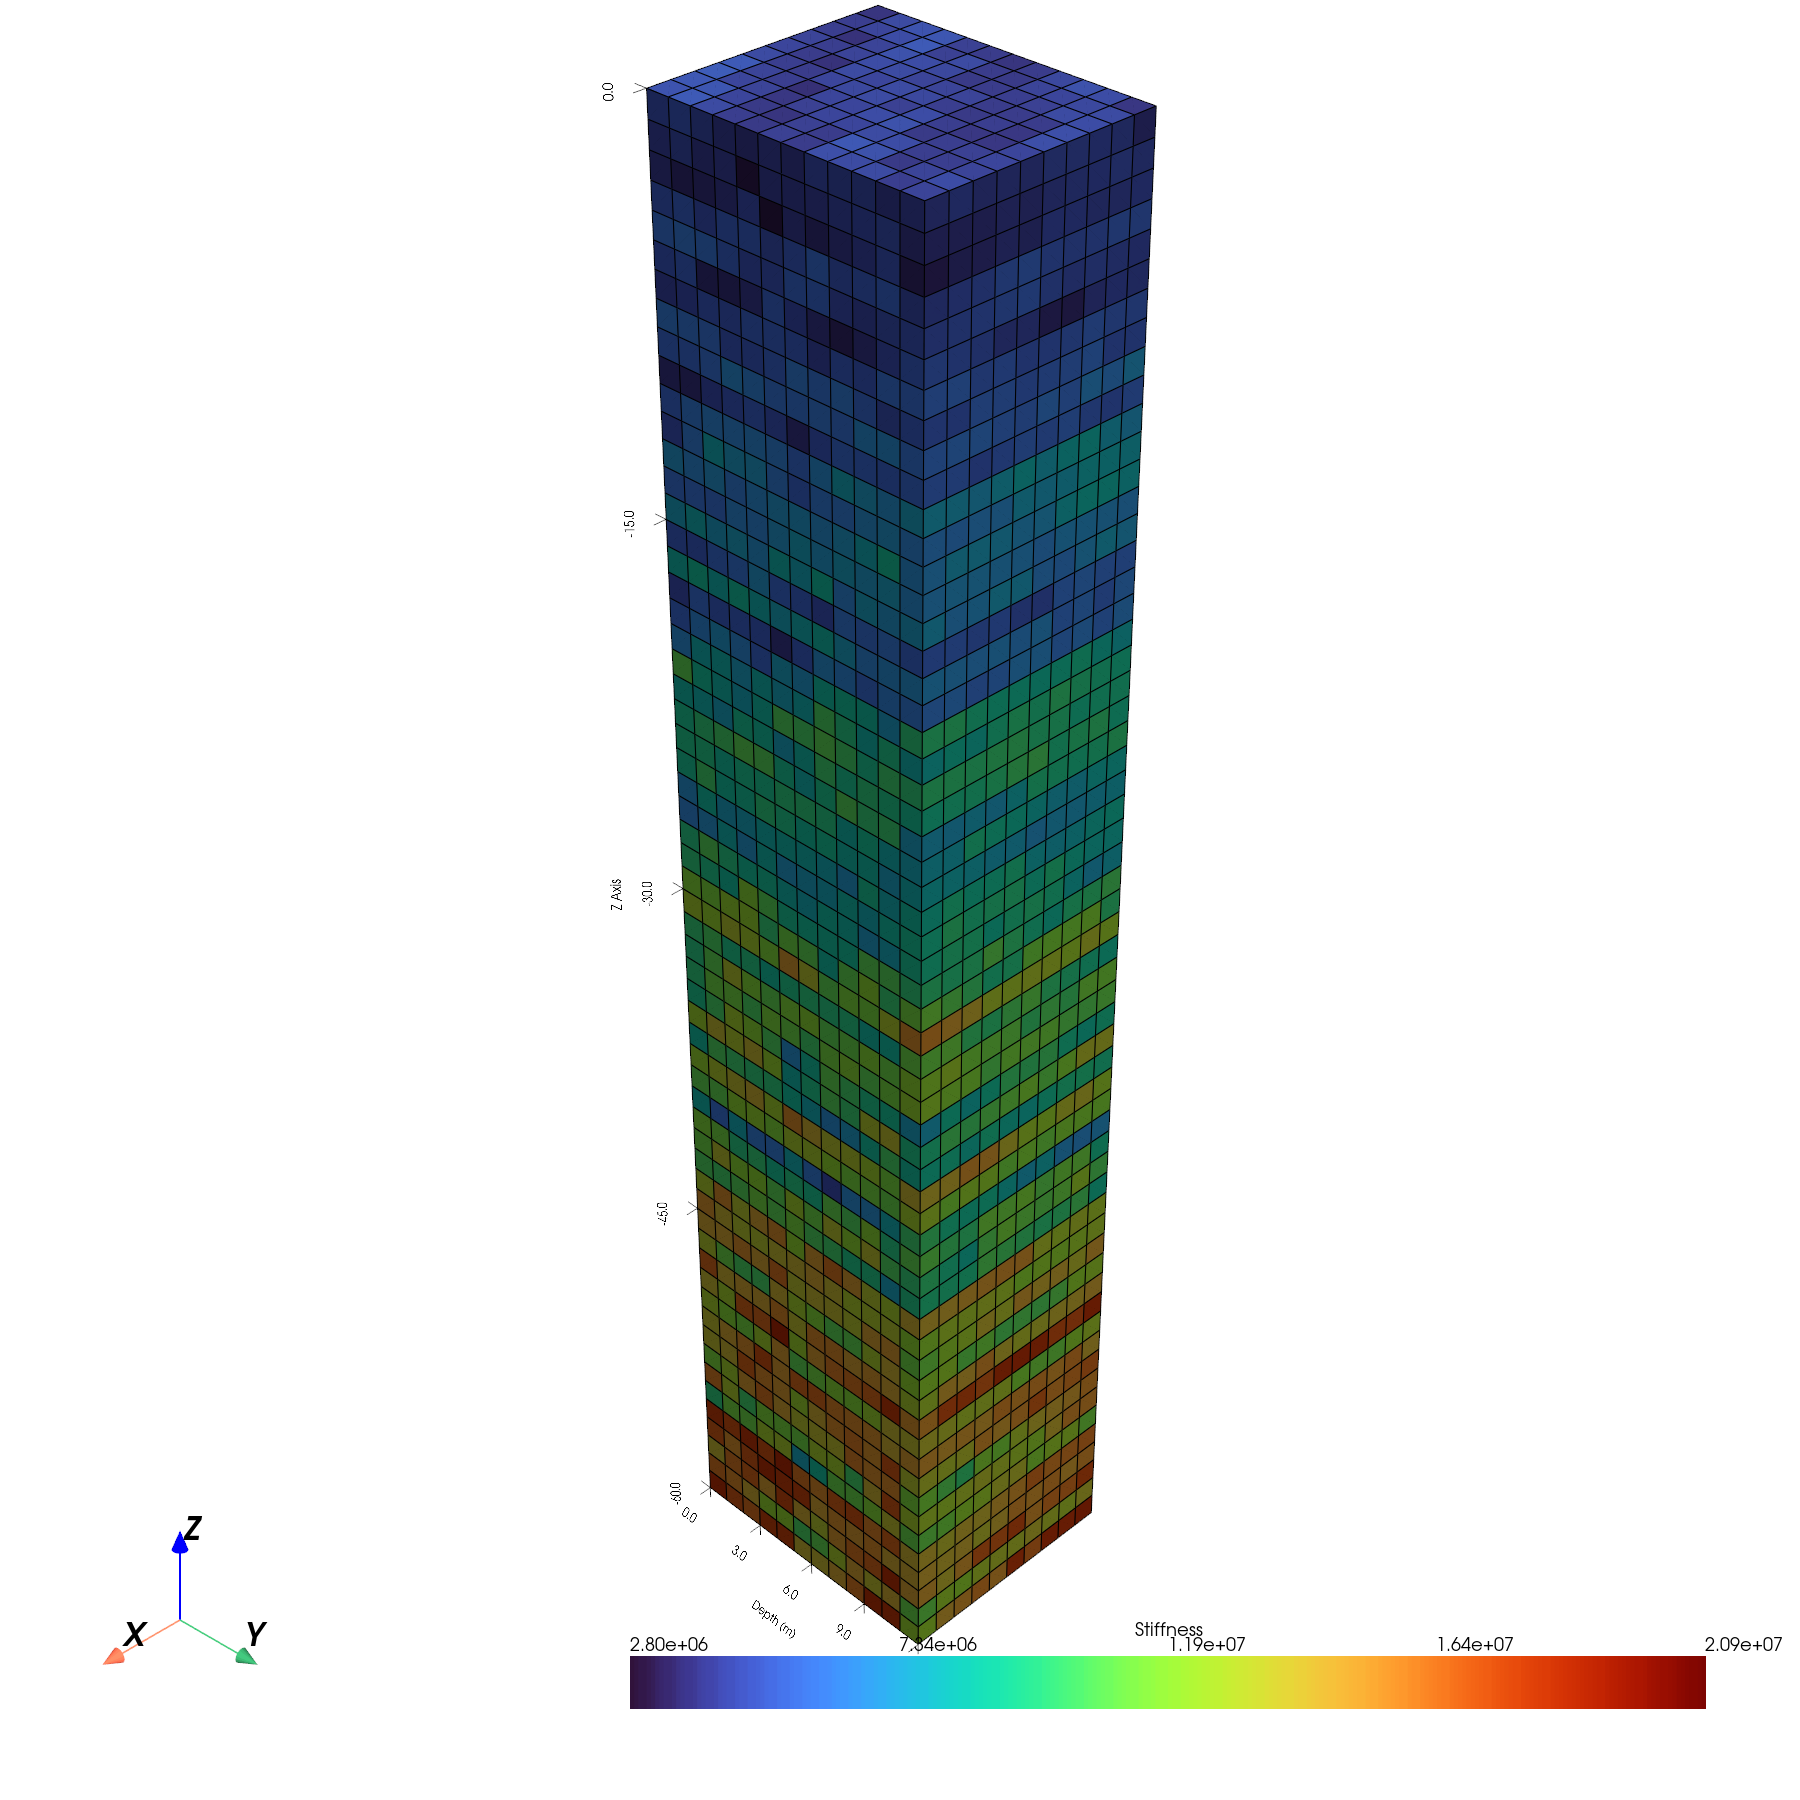

In [15]:
new_mesh = pv.read(vtu_with_stiffness)

pl = pv.Plotter()

pl.add_mesh(new_mesh,  scalars = "Stiffness", show_edges=True, cmap="turbo")
pl.add_axes()
pl.window_size = [1800, 1800]

pl.show_grid(ytitle='Depth (m)', show_xaxis = False, show_xlabels =False, font_family ='arial', font_size=10, bold=False)

pl.show()


Here we draw a graph to visualize the change of stiffness parameter over depth. 

This is a graph of mid x-axis and mid y-axis.

[16521447.92835932 13186196.58788726 16662505.18437925 15136907.82697657
 16271393.46964327  9466092.35936993 10614555.29234537 15675716.08966205
 15256424.0871178  16619646.66151918 11784495.92258604 16852422.92780559
 14764773.12709931  9980911.11256929 13993448.11771608 14445654.88130395
 16098931.23525329 11190515.96795652 11939112.64586672  9679252.77346486
  4692940.79033676 13278430.07597953 12417562.86926712  7087274.97358872
 11239378.01800273  9246443.0647335  10809355.76138476 11424928.98890177
 10837368.04528539 12305833.95140739 10841264.70551894  8451658.11427768
  8211043.15435654  7008756.33698857  7703256.63118349  7725888.73209168
  9254385.60608067 10325046.15723455  9409793.48516944  9712446.98642369
  9346757.48365534  8355717.56759463  6512678.42567414  8243118.95793513
  4427159.18135649  7187846.61836278  7137024.69359096  6424593.81586144
  6357098.64341474  6807495.64046014  4642715.35428075  6170124.56572206
  6664216.3073146   4996689.08962253  3665730.05636

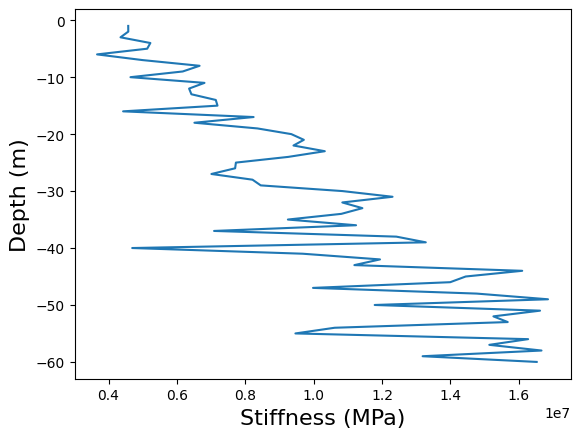

In [16]:
import matplotlib.pyplot as plt
import numpy as np

mid_axis_x = int(number_of_cells_x / 2)
mid_axis_y = int(number_of_cells_y / 2)

xpoints = stiffness_with_RF[:, mid_axis_x, mid_axis_y]
zpoints = np.arange (-depth_of_boundary, 0, 1)

plt.xlabel('Stiffness (MPa)', fontsize=16)
plt.ylabel('Depth (m)', fontsize=16)

print (xpoints)
plt.plot(xpoints, zpoints)
plt.show()

This is a graph of the mean across x axis and y axis.

[16665670.72197453 13580402.82981163 16010956.03706929 16554575.33531405
 16856021.23826052 11070326.33764357 12714919.99104804 14541050.938355
 15075173.25684072 15434361.58483077 12459773.88499829 15932149.68975341
 15214512.843716   11954697.97058124 14595594.80848317 13756608.07655093
 14637904.04280695 10367194.70679801 11884807.10495196 10307437.65225132
  7020640.38048211 11839393.20783328 13481014.211936    9048173.0428698
 11963658.73600973  9841831.36639024 10909246.00315757 11377134.67343118
  9836901.30997383 12504130.82318398 10919913.70398187  9913919.96483031
  8837759.85706911  7780585.20149284  8242620.52770983  8830683.47251566
  9289434.81541628  9703256.38204095  8854798.85710197  9437878.98065739
  8318555.87132132  7523821.58095198  5858372.55616533  8146092.38749131
  5879491.17979181  7441824.86167716  6765694.61685211  7074392.15814387
  6532032.33084518  6722226.35540715  4972394.28915559  6273515.5027758
  5827625.92484812  5132207.87328288  4345380.32312474 

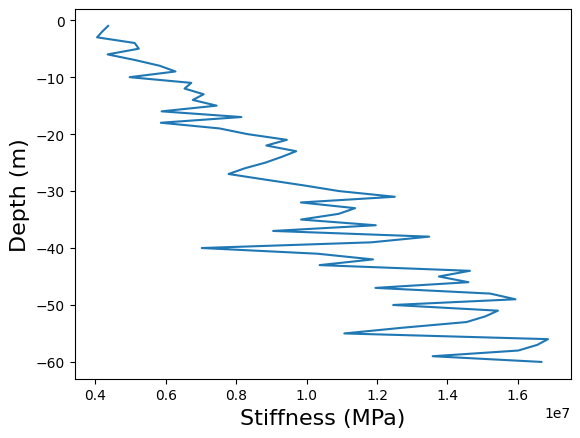

In [17]:
xpoints = np.mean(stiffness_with_RF, axis=1) # take average horizontally
xpoints = np.mean(xpoints, axis=1) # take average horizontally
zpoints = np.arange (-depth_of_boundary, 0, 1)

plt.xlabel('Stiffness (MPa)', fontsize=16)
plt.ylabel('Depth (m)', fontsize=16)

print (xpoints)
plt.plot(xpoints, zpoints)
plt.show()


In [18]:
os.chdir("..")

In [19]:
print(os.getcwd())

c:\Users\glori\Documents\tasks\ogs_exercise\3D
